In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
# Replace with your file path
df = pd.read_excel("../data/Docker_Images_Features.xlsx")  

# Check first few rows
print(df.head())

   Unnamed: 0          Docker Name     Tag Last Update    Size  \
0           4       adminer:latest  latest      9 days   250MB   
1           5  adoptopenjdk:latest  latest   22 months   472MB   
2           9     almalinux:latest  latest     2 weeks   184MB   
3          11          alpine:3.16    3.16     7 weeks  5.54MB   
4          13        alpine:latest    3.16     7 weeks  5.54MB   

  Package Manager     Base Image  # alternative base imgs  \
0             deb    debian:11.7                       12   
1             deb   ubuntu:20.04                        0   
2             rpm            NaN                        0   
3             apk  alpine:3.16.6                        0   
4             apk  alpine:3.18.2                        0   

   number of tested dependencies  number of vulnerabilities  \
0                            152                         66   
1                            132                        131   
2                            150               

In [3]:
# Summary of missing values
print(df.isnull().sum())

Unnamed: 0                         0
Docker Name                        0
Tag                                0
Last Update                        0
Size                               0
Package Manager                    0
Base Image                       333
# alternative base imgs            0
number of tested dependencies      0
number of vulnerabilities          0
Critical Severity                  0
High Severity                      0
Medium Severity                    0
Low Severity                       0
layers                             3
secure                             0
dtype: int64


In [4]:
df['layers'] = df['layers'].fillna(df['layers'].median())  # or 0
df['Base Image'] = df['Base Image'].fillna('Unknown')

In [5]:
drop_cols = ['Docker Name', 'Tag', 'Last Update', 'secure', 'number of vulnerabilities']
df_unsup = df.drop(columns=drop_cols)

In [6]:
# Encode categorical columns
le_pkg = LabelEncoder()
df_unsup['Package Manager'] = le_pkg.fit_transform(df_unsup['Package Manager'])
joblib.dump(le_pkg, "../src/model_store/le_package_unsup.pkl")

le_base = LabelEncoder()
df_unsup['Base Image'] = le_base.fit_transform(df_unsup['Base Image'])
joblib.dump(le_base, "../src/model_store/le_base_unsup.pkl")

['../src/model_store/le_base_unsup.pkl']

In [7]:
def convert_size(size_str):
    size_str = str(size_str).strip()
    try:
        if 'MB' in size_str:
            return float(size_str.replace('MB','').strip())
        elif 'GB' in size_str:
            return float(size_str.replace('GB','').strip()) * 1024
        elif 'kB' in size_str:
            return float(size_str.replace('kB','').strip()) / 1024  # convert kB to MB
        else:
            return float(size_str)  # fallback
    except:
        return 0  # if something else appears, set to 0

# Apply to dataframe
df_unsup['Size'] = df_unsup['Size'].apply(convert_size)

In [8]:
# Fit scaler only on numeric data (all features now numeric)
unsup_features = df_unsup[['Size', 'Package Manager', 'Base Image', '# alternative base imgs',
                           'number of tested dependencies', 'layers']]
scaler = StandardScaler()
scaler.fit(unsup_features)

# Save scaler
joblib.dump(scaler, "../src/model_store/unsupervised_scaler.pkl")
print("Unsupervised preprocessing objects saved successfully!")

Unsupervised preprocessing objects saved successfully!


In [11]:
# Transform the data
df_scaled = pd.DataFrame(scaler.transform(unsup_features), columns=unsup_features.columns)

# Save to CSV
df_scaled.to_csv('../data/preprocessed/unsupervised_preprocessed.csv', index=False)


In [12]:
print(df_unsup.isnull().sum())

Unnamed: 0                       0
Size                             0
Package Manager                  0
Base Image                       0
# alternative base imgs          0
number of tested dependencies    0
Critical Severity                0
High Severity                    0
Medium Severity                  0
Low Severity                     0
layers                           0
dtype: int64


In [13]:
print(df_unsup.dtypes)

Unnamed: 0                         int64
Size                             float64
Package Manager                    int64
Base Image                         int64
# alternative base imgs            int64
number of tested dependencies      int64
Critical Severity                  int64
High Severity                      int64
Medium Severity                    int64
Low Severity                       int64
layers                           float64
dtype: object


In [14]:
# Check for non-numeric values
non_numeric_size = df_unsup[pd.to_numeric(df_unsup['Size'], errors='coerce').isna()]
print(non_numeric_size)

# Check basic statistics
print(df_unsup['Size'].describe())

Empty DataFrame
Columns: [Unnamed: 0, Size, Package Manager, Base Image, # alternative base imgs, number of tested dependencies, Critical Severity, High Severity, Medium Severity, Low Severity, layers]
Index: []
count     778.000000
mean      315.196490
std       447.092266
min         0.001816
25%        72.800000
50%       184.500000
75%       381.000000
max      3901.440000
Name: Size, dtype: float64


In [15]:
# Columns to check
cols_to_check = ['# alternative base imgs', 'number of tested dependencies', 'layers']

for col in cols_to_check:
    print(f"{col} stats:\n", df_unsup[col].describe())
    print(f"Rows with {col} <= 0:\n", df_unsup[df_unsup[col] <= 0])

# alternative base imgs stats:
 count    778.000000
mean       5.372751
std        7.151055
min        0.000000
25%        0.000000
50%        0.000000
75%        8.000000
max       28.000000
Name: # alternative base imgs, dtype: float64
Rows with # alternative base imgs <= 0:
      Unnamed: 0    Size  Package Manager  Base Image  # alternative base imgs  \
1             5  472.00                1         130                        0   
2             9  184.00                3           0                        0   
3            11    5.54                0          10                        0   
4            13    5.54                0          15                        0   
5            14  114.00                3           0                        0   
..          ...     ...              ...         ...                      ...   
773        1125    6.91                2           0                        0   
774        1133    5.54                0          16                     

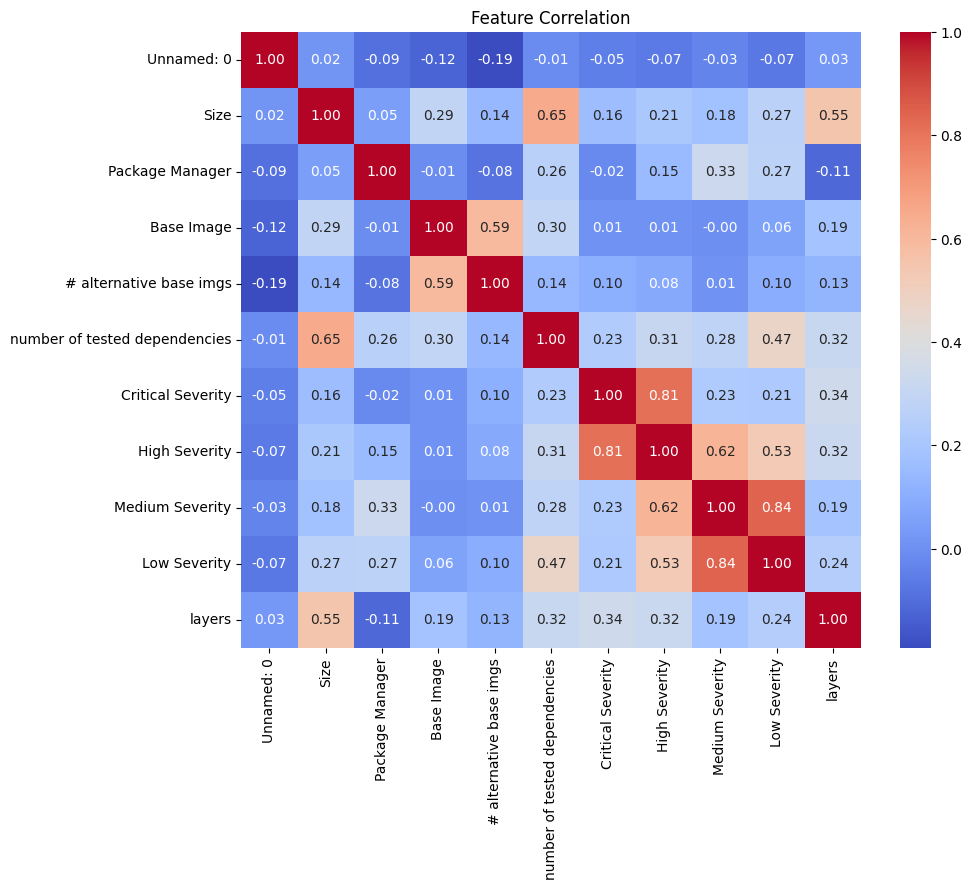

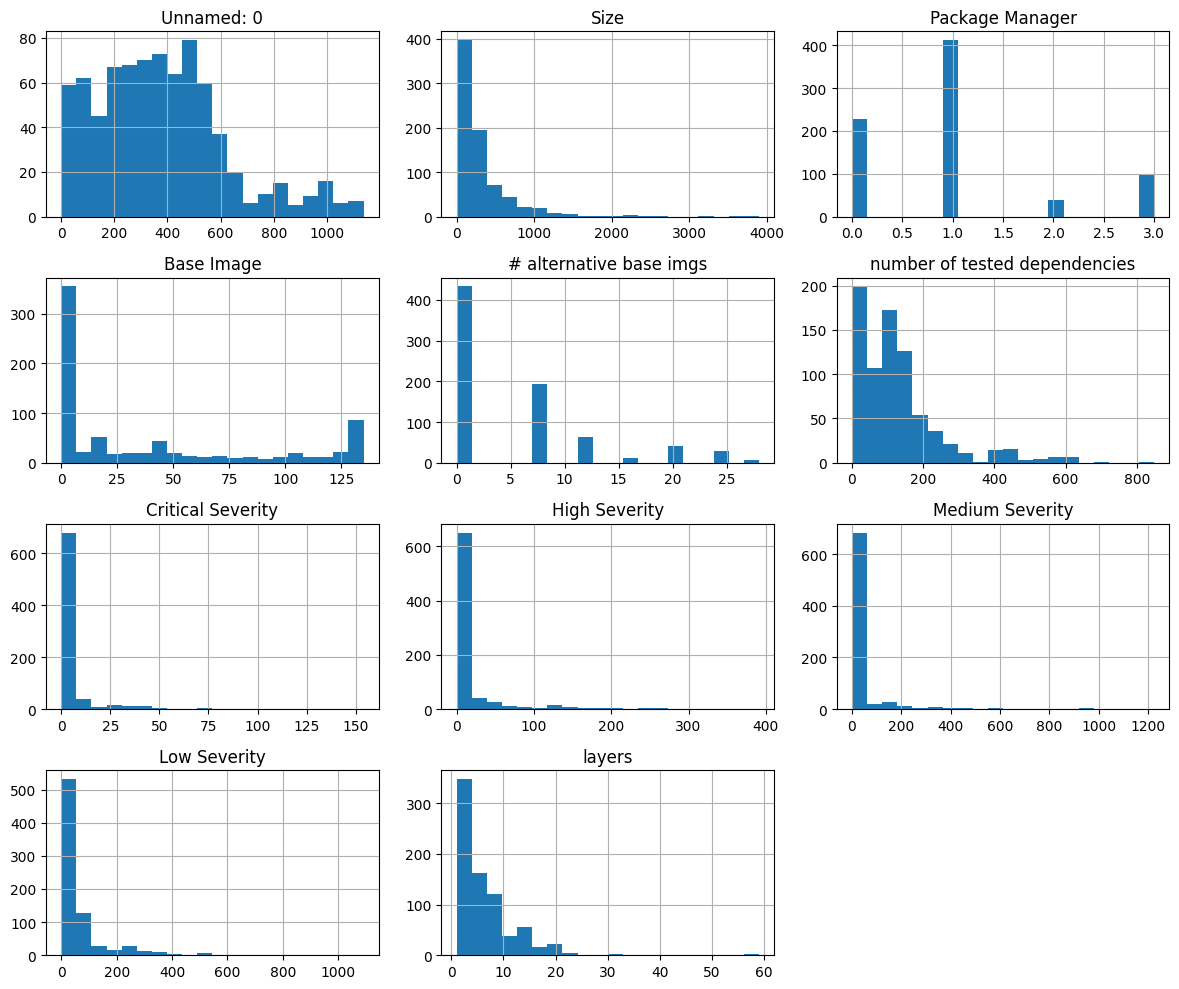

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_unsup.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Distribution of numeric features
numeric_cols = df_unsup.select_dtypes(include=['float64', 'int64']).columns
df_unsup[numeric_cols].hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()